In [1]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain.messages import RemoveMessage

In [3]:
load_dotenv()

True

In [4]:
llm=ChatOpenAI(model='gpt-4o-mini')

In [5]:
def chat(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [7]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [8]:
graph = builder.compile(checkpointer=InMemorySaver())

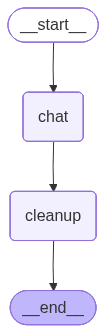

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Harsh"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='f832c626-ccb7-43ef-815a-f913f21baf4a'),
  AIMessage(content="LangChain is a framework designed for building applications with large language models (LLMs). It facilitates the development of applications that can utilize LLMs effectively by providing various components and features for tasks such as prompt management, retrieval-augmented generation, memory, chains, and more.\n\n### Key Features of LangChain:\n\n1. **Chains**: These are sequences of calls that can involve multiple components, such as prompts and APIs. Chains allow developers to create complex workflows that take inputs, process them, and generate outputs in a structured manner.\n\n2. **Prompt Templates**: LangChain provides tools to manage and format prompts systematically. This can include predefined templates that can be filled with user input or dynamically generated data, enhancing the quality and relevance of the 

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
